# Frankenstein Approximation: Helium RESI electron-electron momentum correlation

Combines:
- **Electron 1**: `OrbitFinder`'s saddle-point solve for $t_1$ (ionisation) and $t_2$ (recollision), from which we build $S_A(p_1)$ using the *same* formula as `Action::f12` in the C++ code. We deliberately **discard** OrbitFinder's own $t_3$/electron-2 solution (see the `TODO symmetry considerations` note added to `ResultGrid.cpp`) and replace electron 2's propagation with a genuine CQSFA calculation instead.
- **Electron 2**: `CQSFA_fwd`'s Coulomb-corrected transition amplitude $M_{CQSFA}(p_2)$, computed for a target with $I_p = E_{2e} = 0.5$ a.u. and Coulomb charge $Z=2$ (He$^+$), driven by the *same* laser field ($\omega=0.057$ a.u., $U_p=0.6579$ a.u.) as the OrbitFinder run.

Final map: $M_{FR}(p_{1,\parallel}, p_{2,\parallel}) = A_1(p_{1,\parallel}) \times M_{CQSFA}(p_{2,\parallel})$, at zero perpendicular momentum for both electrons — the standard electron-electron parallel-momentum correlation diagram used in NSDI/RESI studies.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

OrbitFinder_dir = "/workspaces/CQSFA/OrbitFinder/TestingSuite"
CQSFA_dir = "/workspaces/CQSFA/CQSFA_fwd/runs/Frankenstein_He_electron2"

# Laser field (shared by both electrons)
Up, omega = 0.6579, 0.057
Up0 = Up / omega

# Channel ionisation energies (Helium RESI channel from Shaaran et al. PRA 81, 063413 (2010))
Ip1, Ip2, Ip12 = 0.97, 2.0, 0.5  # I1g, I2g, I2e

## Electron 1: $S_A(p_1)$ from OrbitFinder's $t_1, t_2$ saddle times

`Action::f12(e1_long, e1_trans, t1, t2)` depends **only** on electron 1's own momentum and $(t_1,t_2)$ - it never references electron 2's momentum, so it's safe to reuse OrbitFinder's already-solved $(t_1,t_2)$ regardless of the symmetry caveat noted in `ResultGrid.cpp`.

In [6]:
def f12(e1_long, e1_trans, t1, t2):
    """Python translation of OrbitFinder's Action::f12 (electron-1-only action)."""
    p10 = e1_long * np.sqrt(Up0)
    p1tr0 = e1_trans * np.sqrt(Up0)
    ip10 = Ip1 / omega
    ip120 = Ip12 / omega
    ip20 = Ip2 / omega
    sin_t1, sin_2t1, sin_t2 = np.sin(t1), np.sin(2 * t1), np.sin(t2)
    X = (sin_t2 - sin_t1) ** 2 / (t2 - t1)
    return (
        t1 * (Up0 + ip10)
        + t2 * (ip20 - ip120 + 0.5 * (p10 ** 2 + p1tr0 ** 2))
        + sin_2t1 * 0.5 * Up0
        + sin_t2 * 2 * p10 * np.sqrt(Up0)
        + X * 2 * Up0
    )


def load_orbit_file(fname):
    rows = np.loadtxt(fname)
    p_long, p_trans = rows[:, 0], rows[:, 1]
    t1 = rows[:, 2] + 1j * rows[:, 3]
    t2 = rows[:, 4] + 1j * rows[:, 5]
    return p_long, p_trans, t1, t2


def bin_onto_grid(p_long, p_trans, values, decimals=3):
    """Robustly bucket scattered (p_long,p_trans,value) rows onto a regular grid,
    tolerant of tiny floating-point jitter in the printed axis values (OrbitFinder's
    text output occasionally prints a boundary point at slightly different precision)."""
    long_axis = np.unique(np.round(p_long, decimals))
    trans_axis = np.unique(np.round(p_trans, decimals))
    grid = np.full((len(long_axis), len(trans_axis)), np.nan, dtype=values.dtype)
    i_idx = np.searchsorted(long_axis, np.round(p_long, decimals))
    j_idx = np.searchsorted(trans_axis, np.round(p_trans, decimals))
    grid[i_idx, j_idx] = values
    return long_axis, trans_axis, grid


pl_s, pt_s, t1_s, t2_s = load_orbit_file(f"{OrbitFinder_dir}/results/helium_resi_cross.inp_Range_29X29_channel:0.shortorbit")
pl_l, pt_l, t1_l, t2_l = load_orbit_file(f"{OrbitFinder_dir}/results/helium_resi_cross.inp_Range_29X29_channel:0.longorbit")

S_A_short = f12(pl_s, pt_s, t1_s, t2_s)
S_A_long = f12(pl_l, pt_l, t1_l, t2_l)

# Im(S_A) < 0 => |exp(iS_A)| > 1, i.e. a *growing* amplitude, which is unphysical for a
# tunnelling/rescattering saddle-point solution. This happens at a handful of extreme,
# high-energy grid corners where the numerical continuation picks the wrong root. Mask
# those points out rather than let single bogus points with |amp|~1e90 dominate the sum.
with np.errstate(over="ignore"):
    A1_short_flat = np.where(S_A_short.imag >= 0, np.exp(1j * S_A_short), 0.0)
    A1_long_flat = np.where(S_A_long.imag >= 0, np.exp(1j * S_A_long), 0.0)

n_masked_short = np.sum(S_A_short.imag < 0)
n_masked_long = np.sum(S_A_long.imag < 0)

p1_par_axis, p1_perp_axis, A1_short_grid = bin_onto_grid(pl_s, pt_s, A1_short_flat)
_, _, A1_long_grid = bin_onto_grid(pl_l, pt_l, A1_long_flat)

A1_grid = np.nan_to_num(A1_short_grid) + np.nan_to_num(A1_long_grid)
P1_grid = np.abs(A1_grid) ** 2

# Per Eory report Eq. 5.13/Fig. 12: integrate (sum) the probability over the perpendicular
# momentum to get a 1D transition probability W1(p1_parallel) for electron 1 alone.
with np.errstate(invalid="ignore"):
    finite_P1 = np.where(np.isfinite(P1_grid), P1_grid, 0.0)
W1 = finite_P1.sum(axis=1)

print(f"electron 1 grid: {len(p1_par_axis)}x{len(p1_perp_axis)}, p1_par in [{p1_par_axis.min():.3f},{p1_par_axis.max():.3f}]")
print(f"masked {n_masked_short} short-orbit and {n_masked_long} long-orbit points with unphysical Im(S_A)<0 (out of {len(pl_s)} each)")

electron 1 grid: 29x29, p1_par in [-4.315,4.315]
masked 625 short-orbit and 0 long-orbit points with unphysical Im(S_A)<0 (out of 841 each)


## Electron 2: $M_{CQSFA}(p_2)$ from CQSFA_fwd's Amplitude_Grid

In [4]:
import glob

amp_files = glob.glob(f"{CQSFA_dir}/Data/Amplitude_Grid_*.dat")
print("found:", amp_files)
amp_file = amp_files[0]

amp_data = np.loadtxt(amp_file)
pf_z, pf_perp = amp_data[:, 0], amp_data[:, 1]
M_re, M_im = amp_data[:, 3], amp_data[:, 4]
M2_flat = M_re + 1j * M_im

p2_par_axis = np.unique(pf_z)
p2_perp_axis = np.unique(pf_perp)
n2z, n2y = len(p2_par_axis), len(p2_perp_axis)
print(f"electron 2 grid: {n2z}x{n2y}, p2_par in [{p2_par_axis.min():.3f},{p2_par_axis.max():.3f}]")

# Sort into a regular grid indexed by (pf_z, pf_perp)
order = np.lexsort((pf_perp, pf_z))
M2_grid = M2_flat[order].reshape(n2z, n2y)
P2_grid = np.abs(M2_grid) ** 2

# Same integration-over-perpendicular-momentum treatment as electron 1
W2 = P2_grid.sum(axis=1)

found: ['/workspaces/CQSFA/CQSFA_fwd/runs/Frankenstein_He_electron2/Data/Amplitude_Grid_Frankenstein_He_electron2_250X250X1.dat']
electron 2 grid: 250x250, p2_par in [-2.500,2.500]


## Baseline: electron 2 without Coulomb correction (pure SFA, from OrbitFinder's own $t_3$)

To see how much the Coulomb potential actually *changes* the RESI cross, we need a fair
baseline: electron 2's amplitude computed the same (SFA) way as electron 1, i.e. straight from
OrbitFinder's own $t_3$ solution via `Action::f3`, instead of CQSFA. The Coulomb correction is
expected to be a **small perturbation** on top of this SFA baseline, not a dramatic change.

In [8]:
def f3(e2_long, e2_trans, t3):
    """Python translation of OrbitFinder's Action::f3 (electron-2-only, pure-SFA action)."""
    p20 = e2_long * np.sqrt(Up0)
    p2tr0 = e2_trans * np.sqrt(Up0)
    ip120 = Ip12 / omega
    sin_t3, sin_2t3 = np.sin(t3), np.sin(2 * t3)
    return (
        t3 * (0.5 * (p20 ** 2 + p2tr0 ** 2) + Up0 + ip120)
        + sin_t3 * p20 * np.sqrt(4 * Up0)
        + sin_2t3 * 0.5 * Up0
    )


def load_t3(fname):
    rows = np.loadtxt(fname)
    p_long, p_trans = rows[:, 0], rows[:, 1]
    t3 = rows[:, 6] + 1j * rows[:, 7]
    return p_long, p_trans, t3


pl_s3, pt_s3, t3_s = load_t3(f"{OrbitFinder_dir}/results/helium_resi_cross.inp_Range_29X29_channel:0.shortorbit")
pl_l3, pt_l3, t3_l = load_t3(f"{OrbitFinder_dir}/results/helium_resi_cross.inp_Range_29X29_channel:0.longorbit")

S_B_short = f3(pl_s3, pt_s3, t3_s)
S_B_long = f3(pl_l3, pt_l3, t3_l)

with np.errstate(over="ignore"):
    A2_short_flat = np.where(S_B_short.imag >= 0, np.exp(1j * S_B_short), 0.0)
    A2_long_flat = np.where(S_B_long.imag >= 0, np.exp(1j * S_B_long), 0.0)

n_masked_short_e2 = np.sum(S_B_short.imag < 0)
n_masked_long_e2 = np.sum(S_B_long.imag < 0)

p2sfa_par_axis, p2sfa_perp_axis, A2_short_grid = bin_onto_grid(pl_s3, pt_s3, A2_short_flat)
_, _, A2_long_grid = bin_onto_grid(pl_l3, pt_l3, A2_long_flat)

A2_SFA_grid = np.nan_to_num(A2_short_grid) + np.nan_to_num(A2_long_grid)
P2_SFA_grid = np.abs(A2_SFA_grid) ** 2

with np.errstate(invalid="ignore"):
    finite_P2_SFA = np.where(np.isfinite(P2_SFA_grid), P2_SFA_grid, 0.0)
W2_SFA = finite_P2_SFA.sum(axis=1)

print(f"electron 2 (SFA) grid: {len(p2sfa_par_axis)}x{len(p2sfa_perp_axis)}")
print(f"masked {n_masked_short_e2} short-orbit and {n_masked_long_e2} long-orbit points (out of {len(pl_s3)} each)")

electron 2 (SFA) grid: 29x29
masked 0 short-orbit and 0 long-orbit points (out of 841 each)


## Combine: electron-electron parallel-momentum correlation map

Take both electrons at zero perpendicular momentum and form the outer product $M_{FR}(p_{1,\parallel},p_{2,\parallel}) = A_1(p_{1,\parallel},0)\,M_{CQSFA}(p_{2,\parallel},0)$.

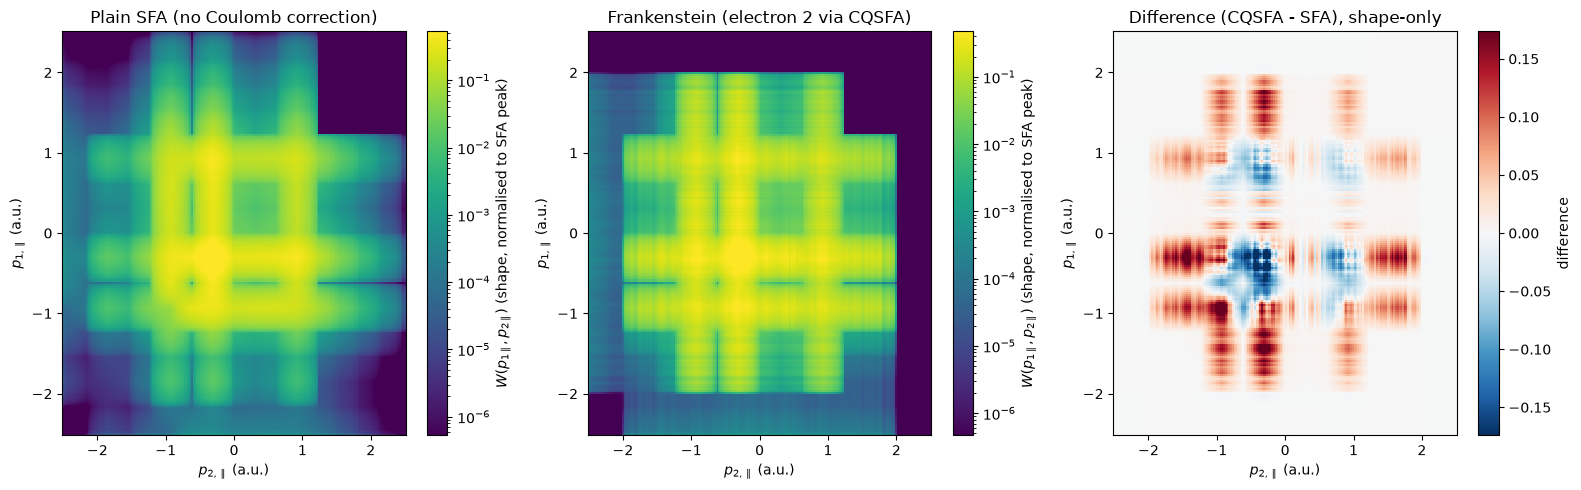

max |shape difference| = 0.2838 (i.e. 28.4% of the SFA peak)


In [11]:
# Interpolate all 1D probability curves onto a common momentum axis (Eory report Sec. 5.3),
# then combine via the outer product (Eq. 5.14, Fig. 12) and symmetrise (p1,p2)<->(p2,p1)
# since the two electrons are indistinguishable at the detector.
#
# NOTE ON NORMALISATION: our SFA baseline for electron 2 (f3, translated from Action::f3) is a
# pure phase factor exp(iS_B) with NO prefactor, whereas CQSFA_fwd's amplitude includes a real,
# physically normalised prefactor - so the two are on incommensurate absolute scales (comparing
# them directly gives a meaningless >1000% "difference" that is just a units mismatch, not
# physics). Since we only ever claimed the "constant prefactor" simplified treatment throughout
# this project, the only fair comparison is of *shape*: normalise each electron's curve to its
# own peak before combining.
p_min = max(p1_par_axis.min(), p2_par_axis.min(), p2sfa_par_axis.min())
p_max = min(p1_par_axis.max(), p2_par_axis.max(), p2sfa_par_axis.max())
p_common = np.linspace(p_min, p_max, 200)

W1_common = np.interp(p_common, p1_par_axis, W1)
W2_common = np.interp(p_common, p2_par_axis, W2)               # electron 2, CQSFA (Coulomb-corrected)
W2_SFA_common = np.interp(p_common, p2sfa_par_axis, W2_SFA)     # electron 2, pure SFA (no Coulomb)

W2_common_n = W2_common / W2_common.max()
W2_SFA_common_n = W2_SFA_common / W2_SFA_common.max()

W_FR_CQSFA = np.outer(W1_common, W2_common_n)      # electron 1 (SFA) x electron 2 (CQSFA)
W_FR_SFA = np.outer(W1_common, W2_SFA_common_n)    # electron 1 (SFA) x electron 2 (SFA) -- baseline

W_FR_CQSFA_sym = W_FR_CQSFA + W_FR_CQSFA.T
W_FR_SFA_sym = W_FR_SFA + W_FR_SFA.T

# Normalise both combined (shape-only) maps by the same reference (SFA baseline's peak) so the
# difference reflects genuine shape redistribution, not an independent re-normalisation artefact.
shared_norm = W_FR_SFA_sym.max()
W_FR_SFA_sym_n = W_FR_SFA_sym / shared_norm
W_FR_CQSFA_sym_n = W_FR_CQSFA_sym / shared_norm
relative_diff = W_FR_CQSFA_sym_n - W_FR_SFA_sym_n

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, data, title in [
    (axes[0], W_FR_SFA_sym_n, "Plain SFA (no Coulomb correction)"),
    (axes[1], W_FR_CQSFA_sym_n, "Frankenstein (electron 2 via CQSFA)"),
]:
    finite_mask = np.isfinite(data) & (data > 0)
    vmax = np.percentile(data[finite_mask], 99.5)
    vmin = vmax * 1e-6
    pcm = ax.pcolormesh(
        p_common, p_common, data,
        norm=LogNorm(vmin=vmin, vmax=vmax), shading="auto", cmap="viridis",
    )
    ax.set_xlabel(r"$p_{2,\parallel}$ (a.u.)")
    ax.set_ylabel(r"$p_{1,\parallel}$ (a.u.)")
    ax.set_title(title)
    fig.colorbar(pcm, ax=ax, label=r"$W(p_{1\parallel},p_{2\parallel})$ (shape, normalised to SFA peak)")

vmax_diff = np.percentile(np.abs(relative_diff), 99.5)
pcm3 = axes[2].pcolormesh(
    p_common, p_common, relative_diff,
    vmin=-vmax_diff, vmax=vmax_diff, shading="auto", cmap="RdBu_r",
)
axes[2].set_xlabel(r"$p_{2,\parallel}$ (a.u.)")
axes[2].set_ylabel(r"$p_{1,\parallel}$ (a.u.)")
axes[2].set_title("Difference (CQSFA - SFA), shape-only")
fig.colorbar(pcm3, ax=axes[2], label="difference")

plt.tight_layout()
plt.show()

print(f"max |shape difference| = {np.abs(relative_diff).max():.4f} (i.e. {np.abs(relative_diff).max()*100:.1f}% of the SFA peak)")